# K-Means and Autoencoder Clustering Comparison

This notebook compares two clustering pipelines on customer segmentation data:

1. Standard K-Means on preprocessed features.
2. K-Means on learned latent features from an autoencoder.

Tutor-requested metric included: `v_measure_score` (using `Gender` as a reference label for sanity-check only).

## 1. Import Required Libraries

In [11]:
pip install TensorFlow 

  Using cached protobuf-7.34.1-cp310-abi3-win_amd64.whl.metadata (595 bytes)
   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   ---------------------------------------- 2.6/351.2 MB 16.2 MB/s eta 0:00:22
   - -------------------------------------- 10.2/351.2 MB 27.8 MB/s eta 0:00:13
   - -------------------------------------- 10.5/351.2 MB 27.9 MB/s eta 0:00:13
   - -------------------------------------- 10.5/351.2 MB 27.9 MB/s eta 0:00:13
   - -------------------------------------- 10.5/351.2 MB 27.9 MB/s eta 0:00:13
   - -------------------------------------- 12.8/351.2 MB 10.6 MB/s eta 0:00:32
   - -------------------------------------- 16.8/351.2 MB 12.4 MB/s eta 0:00:28
   - -------------------------------------- 16.8/351.2 MB 12.4 MB/s eta 0:00:28
   - -------------------------------------- 16.8/351.2 MB 12.4 MB/s eta 0:00:28
   - -------------------------------------- 16.8/351.2 MB 12.4 MB/s eta 0:00:28
   - -------------------------------------- 16.8/351.

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.51.0 requires protobuf<7,>=3.20, but you have protobuf 7.34.1 which is incompatible.


In [18]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, v_measure_score

# Autoencoder is optional; notebook will fallback to PCA latent space if TensorFlow is unavailable.
TF_AVAILABLE = True
try:
    import tensorflow as tf
    from tensorflow.keras import layers, Model
except Exception as e:
    TF_AVAILABLE = False
    TF_IMPORT_ERROR = str(e)

sns.set_theme(style='whitegrid')
np.random.seed(42)

if not TF_AVAILABLE:
    print('TensorFlow not available. Autoencoder section will use PCA fallback.')
    print(f'Reason: {TF_IMPORT_ERROR}')

## 2. Load and Prepare Data

In [19]:
X_scaled = pd.read_csv('data/data_preprocessed.csv')
raw_df = pd.read_csv('data/Shopping Mall Customer Segmentation Data .csv')
reference_labels = raw_df['Gender']

print('Scaled feature matrix shape:', X_scaled.shape)
print('Raw data shape:', raw_df.shape)
print('Reference label size:', reference_labels.shape)
print('\nScaled feature preview:')
display(X_scaled.head())

Scaled feature matrix shape: (15079, 4)
Raw data shape: (15079, 5)
Reference label size: (15079,)

Scaled feature preview:


,Age,Gender,Annual_Income,Spending_Score
0,-0.666667,0.0,0.465394,0.775510
1,0.111111,-1.0,0.835265,0.897959
2,0.222222,-1.0,-0.421253,0.510204
3,-0.861111,0.0,-0.591304,0.122449
4,-0.833333,0.0,0.490409,0.510204


## 3. Evaluate K-Means Across k Values

In [20]:
standard_rows = []
for k in range(2, 11):
    model = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels = model.fit_predict(X_scaled)
    standard_rows.append({
        'k': k,
        'inertia': model.inertia_,
        'silhouette': silhouette_score(X_scaled, labels),
        'v_measure_vs_gender': v_measure_score(reference_labels, labels)
    })

standard_scores = pd.DataFrame(standard_rows)
print('Standard K-Means evaluation table:')
display(standard_scores)

Standard K-Means evaluation table:


,k,inertia,silhouette,v_measure_vs_gender
0,2,15260.079905,0.194807,0.000076
1,3,13017.848807,0.181685,0.000128
2,4,11111.910372,0.202347,0.000254
3,5,9911.853519,0.209124,0.235692
4,6,8956.067478,0.217194,0.356741
5,7,8092.815916,0.236119,0.437680
6,8,7361.659694,0.233796,0.365673
7,9,6633.213579,0.254039,0.427903
8,10,6092.601450,0.257027,0.415369


## 4. Train Final K-Means Model and Visualize Clusters

Best k (standard pipeline): 10
Inertia: 6092.60
Silhouette: 0.2570
V-measure vs Gender: 0.4154

Cluster counts:
Cluster
0    1480
1    1471
2    1332
3    1761
4    1743
5    1286
6    1345
7    1572
8    1396
9    1693
Name: count, dtype: int64


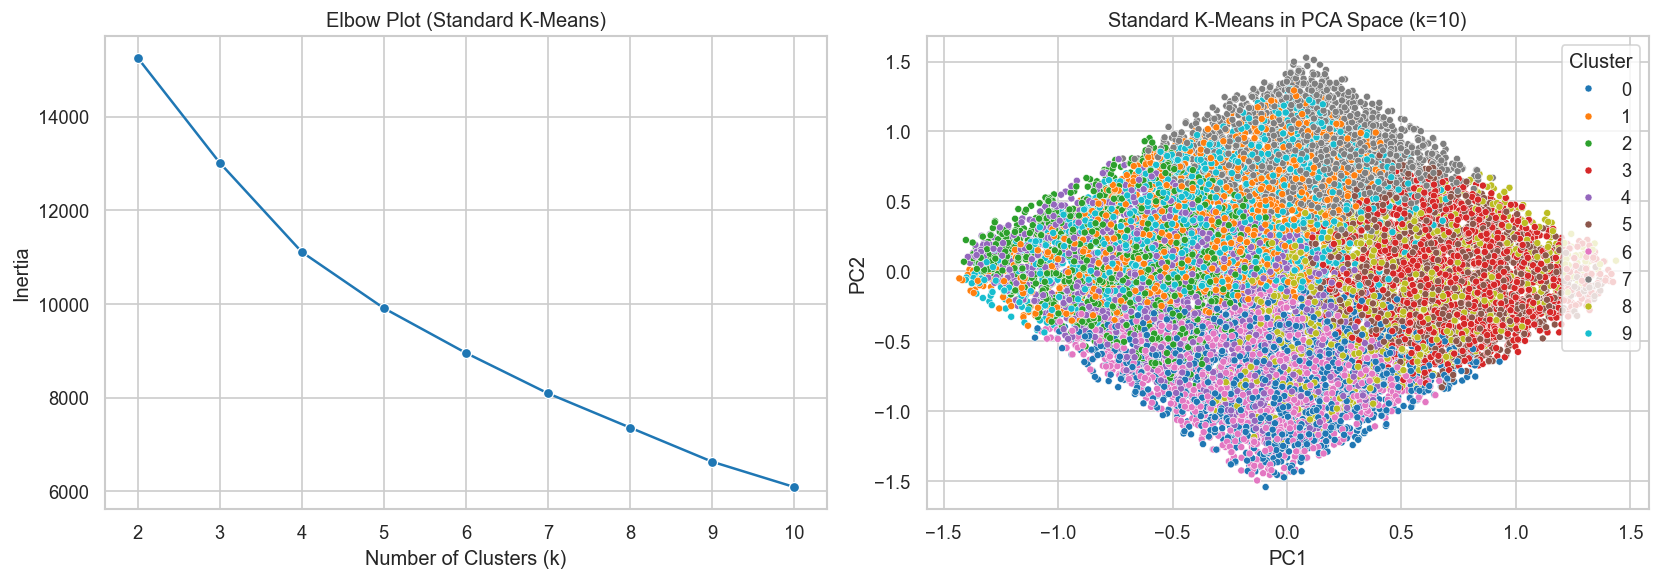

In [21]:
best_k_standard = int(standard_scores.loc[standard_scores['silhouette'].idxmax(), 'k'])

kmeans_standard = KMeans(n_clusters=best_k_standard, random_state=42, n_init='auto')
standard_labels = kmeans_standard.fit_predict(X_scaled)

standard_clustered_df = X_scaled.copy()
standard_clustered_df['Cluster'] = standard_labels

pca_vis = PCA(n_components=2, random_state=42)
standard_vis = pd.DataFrame(pca_vis.fit_transform(X_scaled), columns=['PC1', 'PC2'])
standard_vis['Cluster'] = standard_labels

standard_inertia = kmeans_standard.inertia_
standard_silhouette = silhouette_score(X_scaled, standard_labels)
standard_v_measure = v_measure_score(reference_labels, standard_labels)

print(f'Best k (standard pipeline): {best_k_standard}')
print(f'Inertia: {standard_inertia:.2f}')
print(f'Silhouette: {standard_silhouette:.4f}')
print(f'V-measure vs Gender: {standard_v_measure:.4f}')
print('\nCluster counts:')
print(standard_clustered_df['Cluster'].value_counts().sort_index())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.lineplot(data=standard_scores, x='k', y='inertia', marker='o', ax=axes[0], color='#1f77b4')
axes[0].set_title('Elbow Plot (Standard K-Means)')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')

sns.scatterplot(data=standard_vis, x='PC1', y='PC2', hue='Cluster', palette='tab10', s=18, ax=axes[1], legend='full')
axes[1].set_title(f'Standard K-Means in PCA Space (k={best_k_standard})')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].legend(title='Cluster', loc='best')

plt.tight_layout()
plt.show()

## 5. Build and Train an Autoencoder for Feature Learning

In [22]:
if TF_AVAILABLE:
    tf.random.set_seed(42)

    input_dim = X_scaled.shape[1]
    input_layer = layers.Input(shape=(input_dim,))
    encoded = layers.Dense(8, activation='relu')(input_layer)
    encoded = layers.Dense(2, activation='linear', name='latent')(encoded)
    decoded = layers.Dense(8, activation='relu')(encoded)
    decoded = layers.Dense(input_dim, activation='linear')(decoded)

    autoencoder = Model(inputs=input_layer, outputs=decoded)
    encoder = Model(inputs=input_layer, outputs=autoencoder.get_layer('latent').output)

    autoencoder.compile(optimizer='adam', loss='mse')
    history = autoencoder.fit(
        X_scaled,
        X_scaled,
        epochs=30,
        batch_size=256,
        validation_split=0.2,
        verbose=0
    )

    latent_features = encoder.predict(X_scaled, verbose=0)
    latent_df = pd.DataFrame(latent_features, columns=['Latent1', 'Latent2'])

    print('Autoencoder training completed.')
    print(f"Final train loss: {history.history['loss'][-1]:.6f}")
    print(f"Final validation loss: {history.history['val_loss'][-1]:.6f}")
else:
    # Fallback path when TensorFlow is not available
    latent_pca = PCA(n_components=2, random_state=42)
    latent_features = latent_pca.fit_transform(X_scaled)
    latent_df = pd.DataFrame(latent_features, columns=['Latent1', 'Latent2'])

    print('Using PCA fallback as autoencoder latent representation (TensorFlow unavailable).')

Autoencoder training completed.
Final train loss: 0.127756
Final validation loss: 0.127717


## 6. Cluster Latent Features with K-Means and Compare with Standard Pipeline

In [23]:
latent_rows = []
for k in range(2, 11):
    km_latent = KMeans(n_clusters=k, random_state=42, n_init='auto')
    labels_latent = km_latent.fit_predict(latent_df)

    latent_rows.append({
        'k': k,
        'inertia': km_latent.inertia_,
        'silhouette': silhouette_score(latent_df, labels_latent),
        'v_measure_vs_gender': v_measure_score(reference_labels, labels_latent)
    })

latent_scores = pd.DataFrame(latent_rows)
latent_scores

,k,inertia,silhouette,v_measure_vs_gender
0,2,7490.510742,0.404791,0.002419
1,3,5109.940430,0.384863,0.002965
2,4,3809.583496,0.379878,0.022238
3,5,3076.100342,0.363828,0.021858
4,6,2530.406738,0.366807,0.040189
5,7,2163.814209,0.369756,0.043861
6,8,1899.754395,0.362179,0.055630
7,9,1736.632812,0.357015,0.054131
8,10,1548.653076,0.356276,0.079701


Best k (latent pipeline): 2
Inertia: 7490.51
Silhouette: 0.4048
V-measure vs Gender: 0.0024

Cluster counts:
Cluster
0    6511
1    8568
Name: count, dtype: int64


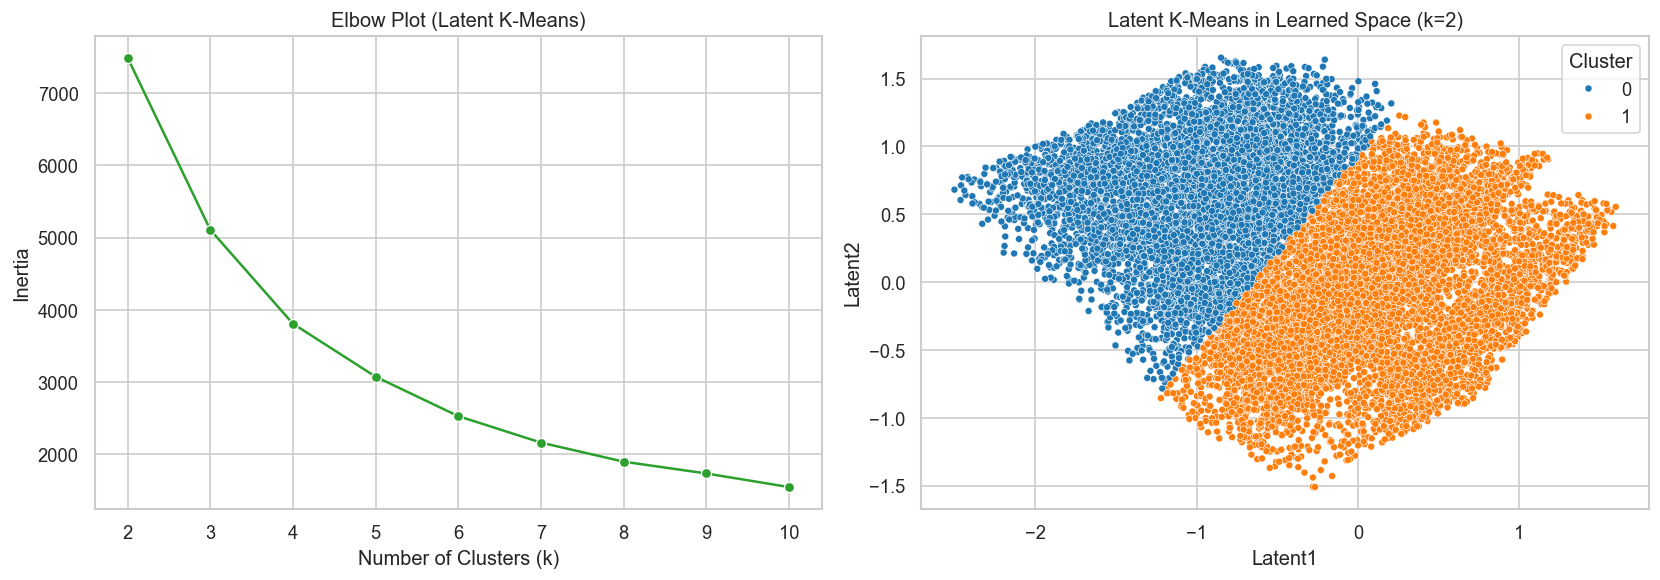

In [24]:
best_k_latent = int(latent_scores.loc[latent_scores['silhouette'].idxmax(), 'k'])

kmeans_latent = KMeans(n_clusters=best_k_latent, random_state=42, n_init='auto')
latent_labels = kmeans_latent.fit_predict(latent_df)

latent_clustered_df = X_scaled.copy()
latent_clustered_df['Cluster'] = latent_labels

latent_inertia = kmeans_latent.inertia_
latent_silhouette = silhouette_score(latent_df, latent_labels)
latent_v_measure = v_measure_score(reference_labels, latent_labels)

print(f'Best k (latent pipeline): {best_k_latent}')
print(f'Inertia: {latent_inertia:.2f}')
print(f'Silhouette: {latent_silhouette:.4f}')
print(f'V-measure vs Gender: {latent_v_measure:.4f}')
print('\nCluster counts:')
print(latent_clustered_df['Cluster'].value_counts().sort_index())

latent_vis = latent_df.copy()
latent_vis['Cluster'] = latent_labels

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.lineplot(data=latent_scores, x='k', y='inertia', marker='o', ax=axes[0], color='#2ca02c')
axes[0].set_title('Elbow Plot (Latent K-Means)')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')

sns.scatterplot(data=latent_vis, x='Latent1', y='Latent2', hue='Cluster', palette='tab10', s=18, ax=axes[1], legend='full')
axes[1].set_title(f'Latent K-Means in Learned Space (k={best_k_latent})')
axes[1].set_xlabel('Latent1')
axes[1].set_ylabel('Latent2')
axes[1].legend(title='Cluster', loc='best')

plt.tight_layout()
plt.show()

## 7. Save Outputs and Summarize Results

In [25]:
standard_output_path = os.path.join('data', 'kmeans_clustered_standard.csv')
latent_output_path = os.path.join('data', 'kmeans_clustered_latent.csv')

standard_clustered_df.to_csv(standard_output_path, index=False)
latent_clustered_df.to_csv(latent_output_path, index=False)

comparison_df = pd.DataFrame([
    {
        'pipeline': 'Standard Scaled Features',
        'best_k': best_k_standard,
        'inertia': standard_inertia,
        'silhouette': standard_silhouette,
        'v_measure_vs_gender': standard_v_measure
    },
    {
        'pipeline': 'Autoencoder/PCA Latent Features',
        'best_k': best_k_latent,
        'inertia': latent_inertia,
        'silhouette': latent_silhouette,
        'v_measure_vs_gender': latent_v_measure
    }
])

comparison_df

print(f'\nSaved standard clustered data to: {standard_output_path}')
print(f'Saved latent clustered data to: {latent_output_path}')


Saved standard clustered data to: data\kmeans_clustered_standard.csv
Saved latent clustered data to: data\kmeans_clustered_latent.csv
